<a href="https://colab.research.google.com/github/dee431/-Badminton-Player-Performance-Dataset/blob/main/Badminton_Player_Performance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cell 1: Import Libraries & Load Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
# Ensure "1. Dataset-selected-columns.csv" is uploaded to your Colab session
df = pd.read_csv("1. Dataset-selected-columns.csv")

# Display the first few rows and dataset info
display(df.head())
print("\nDataset Info:")
df.info()

,Rank,Points,Tournaments,Name,Nationality,Age,Height_cm,Weight_kg,Handedness,Matches_Played
0,1,98715,14,Axelsen Viktor,Denmark,26,177,65,Right,100
1,2,90984,19,Shi Yu Qi,China,22,187,72,Right,82
2,3,85101,20,Ginting Anthony Sinisuka,Indonesia,28,177,64,Right,115
3,4,83594,19,Antonsen Anders,Denmark,29,183,68,Right,101
4,5,81531,19,Christie Jonatan,Indonesia,19,173,58,Right,126



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Rank            100 non-null    int64 
 1   Points          100 non-null    int64 
 2   Tournaments     100 non-null    int64 
 3   Name            100 non-null    object
 4   Nationality     100 non-null    object
 5   Age             100 non-null    int64 
 6   Height_cm       100 non-null    int64 
 7   Weight_kg       100 non-null    int64 
 8   Handedness      100 non-null    object
 9   Matches_Played  100 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 7.9+ KB


# **Cell 2: Exploratory Data Analysis (EDA)**

,Rank,Points,Tournaments,Age,Height_cm,Weight_kg,Matches_Played
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,50.500000,38697.760000,19.500000,25.300000,178.95000,64.320000,122.530000
std,29.011492,19826.411848,5.151248,2.516611,5.84717,3.659442,39.297481
min,1.000000,18430.000000,8.000000,19.000000,166.00000,58.000000,41.000000
25%,25.750000,22754.000000,16.000000,23.750000,174.75000,61.000000,92.250000
50%,50.500000,32638.500000,20.000000,25.500000,178.00000,64.000000,119.500000
75%,75.250000,50407.750000,23.000000,27.000000,182.25000,67.000000,144.250000
max,100.000000,98715.000000,31.000000,32.000000,195.00000,75.000000,233.000000


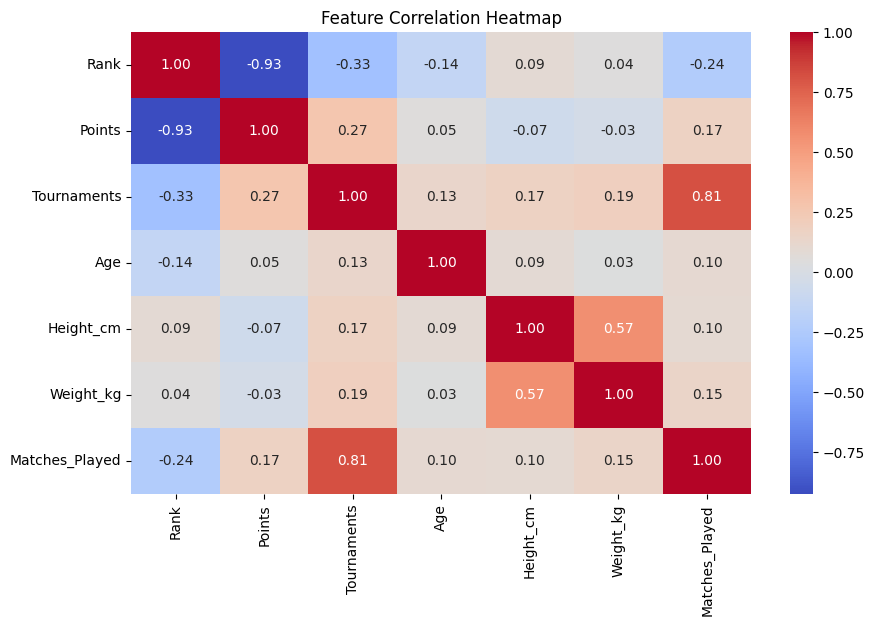

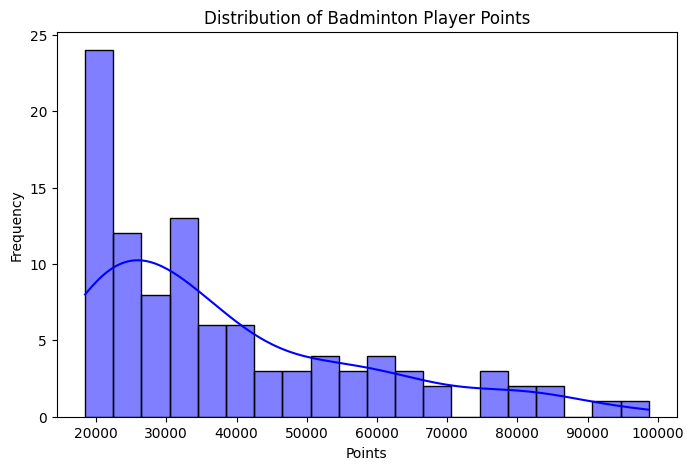

In [3]:
# Generate a statistical summary
display(df.describe())

# Plot a correlation matrix for numerical features
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Visualize the distribution of the Target Variable (Points)
plt.figure(figsize=(8, 5))
sns.histplot(df['Points'], bins=20, kde=True, color='blue')
plt.title("Distribution of Badminton Player Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

# **Cell 3: Data Preprocessing & Splitting**

In [4]:
# Define target and features
# Drop 'Rank' (target leak) and 'Name' (unique identifier)
X = df.drop(columns=['Points', 'Rank', 'Name'])
y = df['Points']

# Categorize columns for distinct preprocessing strategies
categorical_cols = ['Nationality', 'Handedness']
numerical_cols = ['Tournaments', 'Age', 'Height_cm', 'Weight_kg', 'Matches_Played']

# Create a preprocessing pipeline (Scales numbers, One-Hot Encodes categories)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (80, 7)
Testing data shape: (20, 7)


# **Cell 4: Model Selection & Baseline Training**

In [5]:
# Define a dictionary of models to test
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train and evaluate each baseline model
results = {}
for name, model in models.items():
    # Build the full pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

# Compare model performance
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by="R2 Score", ascending=False))

,MAE,RMSE,R2 Score
Random Forest,14450.124000,20378.065330,0.121831
Gradient Boosting,15876.662997,21702.888600,0.003936
Ridge Regression,18114.329270,24577.127565,-0.277363


# **Cell 5: Hyperparameter Tuning (Random Forest)**

In [6]:
# Based on standard performance with mixed tabular data, we tune the Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestRegressor(random_state=42))])

# Define the grid of hyperparameters to search
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Execute Grid Search with 5-fold Cross-Validation
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Extract the best model from the search
best_model = grid_search.best_estimator_

print("\nBest Parameters Discovered:")
print(grid_search.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters Discovered:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}


# **Cell 6: Final Evaluation & Feature Importance Extract**

--- Tuned Model Performance ---
MAE: 14218.53
RMSE: 20308.37
R2 Score: 0.1278


/tmp/ipykernel_2611/3870521799.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


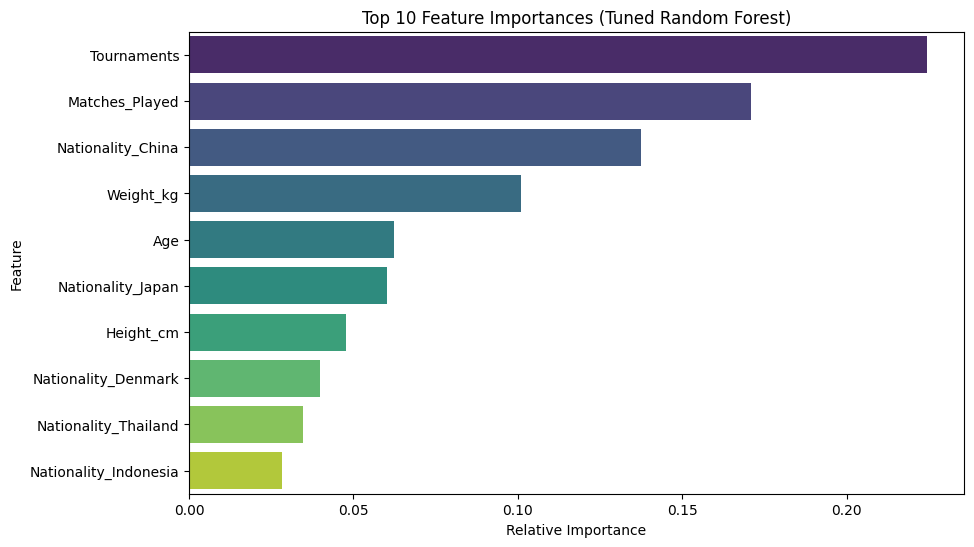

In [7]:
# Evaluate the tuned model on the unseen test set
y_pred_best = best_model.predict(X_test)

print("--- Tuned Model Performance ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_best):.4f}")

# Extract feature names from the OneHotEncoder
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(cat_features)

# Retrieve feature importance scores
importances = best_model.named_steps['model'].feature_importances_

# Map scores to feature names
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most influential features driving the model's predictions
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()